# Propagación de Ondas de Alfvén mediante RK2

En este trabajo se implementa un solver numérico para la propagación de ondas de Alfvén lineales en una dimensión utilizando un esquema RK2 (opción B del trabajo) 
para la integración temporal y diferencias centradas para las derivadas espaciales.

El sistema de ecuaciones linealizadas utilizado es

$$\frac{\partial \delta v}{\partial t} = \frac{B_0}{\mu_0\rho_0} \frac{\partial \delta B}{\partial x}$$
$$\frac{\partial \delta B}{\partial t} = B_0 \frac{\partial \delta v}{\partial x}$$

La velocidad de Alfvén teórica está dada por

$$v_A=\frac{B_0}{\sqrt{\mu_0\rho_0}}$$

El objetivo es estudiar la propagación de la onda, la convergencia del método, su estabilidad numérica y comparar los resultados con los obtenidos mediante PLUTO.

Primero comenzamos definiendo el código:

In [43]:
#Liberias
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["font.size"] = 12

#Operador espacial
def ddx(f, dx):
    """
    Derivada centrada periódica.
    """
    return (np.roll(f,-1) - np.roll(f,1))/(2*dx)

#RHS del sis
def rhs(dv, dB, B0, rho0, mu0, dx):

    dv_t = (B0/(mu0*rho0))*ddx(dB, dx)
    dB_t = B0*ddx(dv, dx)

    return dv_t, dB_t

#Solver RK2 (Utilizando el dado por el profesor, opción B, Santiago me ayudó también :D)



def simulate_alfven(
        N=256,
        L=1.0,
        A=0.1,
        B0=1.0,
        rho0=1.0,
        mu0=1.0,
        CFL=0.8,
        tmax=1.0):

    vA = B0/np.sqrt(mu0*rho0)

    dx = L/N
    dt = CFL*dx/vA

    x = np.linspace(0,L,N,endpoint=False)

    dv = A*np.sin(2*np.pi*x/L)
    dB = A*np.sin(2*np.pi*x/L)

    t = 0.0

    while t < tmax:

        dt_step = min(dt, tmax - t)

        dv1, dB1 = rhs(dv,dB,B0,rho0,mu0,dx)

        dv_star = dv + dt_step*dv1
        dB_star = dB + dt_step*dB1

        dv2, dB2 = rhs(
            dv_star,dB_star,
            B0,rho0,mu0,dx
        )

        dv += 0.5*dt_step*(dv1+dv2)
        dB += 0.5*dt_step*(dB1+dB2)

        t += dt_step

    return x,dv,dB,vA

# Pregunta 1: Perfil y velocidad de propagación

Se estudia la evolución temporal de la perturbación de velocidad

$$\delta v(x,t)$$

para los tiempos

$$t=0,\;0.5,\;1.0,\;2.0$$

Posteriormente se mide numéricamente la velocidad de propagación de la onda siguiendo la posición del máximo de la perturbación y se compara con la velocidad de Alfvén teórica.

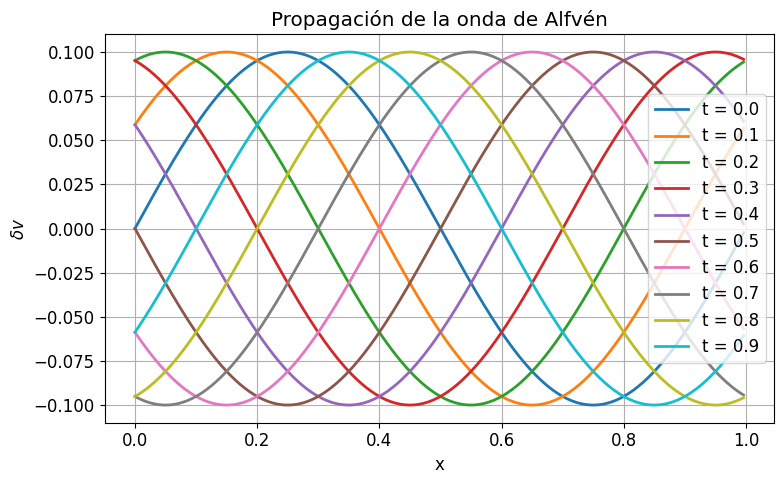

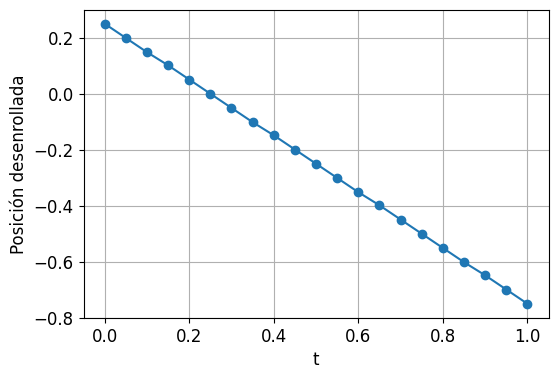

Velocidad numérica = 0.9995941558441558
Velocidad teórica = 1.0
Error relativo = 0.00040584415584421496


In [44]:
#Snapshots
times = np.arange(0,1.0,0.1)

solutions = {}

for t in times:
    x,dv,dB,vA = simulate_alfven(
        N=256,
        CFL=0.8,
        tmax=t
    )

    solutions[t] = dv

plt.figure(figsize=(8,5))

for t in times:
    plt.plot(
        x,
        solutions[t],
        linewidth=2,
        label=f"t = {t:.1f}"
    )

#Grafica
plt.xlabel("x")
plt.ylabel(r"$\delta v$")
plt.title("Propagación de la onda de Alfvén")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#Xpeak
times = np.linspace(0,1,21)

xpeak = []

for t in times:

    x,dv,dB,vA = simulate_alfven(
        N=256,
        CFL=0.8,
        tmax=t
    )

    xpeak.append(x[np.argmax(dv)])

xpeak = np.array(xpeak)

#Velocidad 
xpeak_unwrapped = xpeak.copy()

for i in range(1,len(xpeak_unwrapped)):

    if xpeak_unwrapped[i] - xpeak_unwrapped[i-1] > 0.5:
        xpeak_unwrapped[i:] -= 1.0

plt.figure(figsize=(6,4))
plt.plot(times,xpeak_unwrapped,'o-')
plt.xlabel("t")
plt.ylabel("Posición desenrollada")
plt.grid()
plt.show()

#Ajuste (lineal)
coef = np.polyfit(times, xpeak_unwrapped, 1)

slope = coef[0]

v_num = abs(slope)

print("Velocidad numérica =", v_num)
print("Velocidad teórica =", vA)
print("Error relativo =", abs(v_num-vA)/vA)

La pendiente obtenida es negativa debido a que la perturbación se propaga hacia valores decrecientes de x. Sin embargo, la velocidad física corresponde a la magnitud de dicha pendiente.

$$v_{\rm num}=|dx_{\rm peak}/dt|$$

El valor obtenido coincide con la velocidad de Alfvén teórica \(v_A=1\).

# Pregunta 2: Error L1 vs resolución

Para estudiar la convergencia del método se calcula el error L1 entre la solución numérica y la solución analítica para distintas resoluciones espaciales.

Las simulaciones se ejecutan para

$$N = 32,\;64,\;128,\;256$$

y se comparan con la solución exacta al tiempo

$$t = 1$$

Posteriormente se construye una gráfica log-log del error L1 en función de la resolución y se estima el orden de convergencia mediante un ajuste lineal.

N= 32   L1=9.812316e-04
N= 64   L1=2.348640e-04
N=128   L1=5.805357e-05
N=256   L1=1.447144e-05


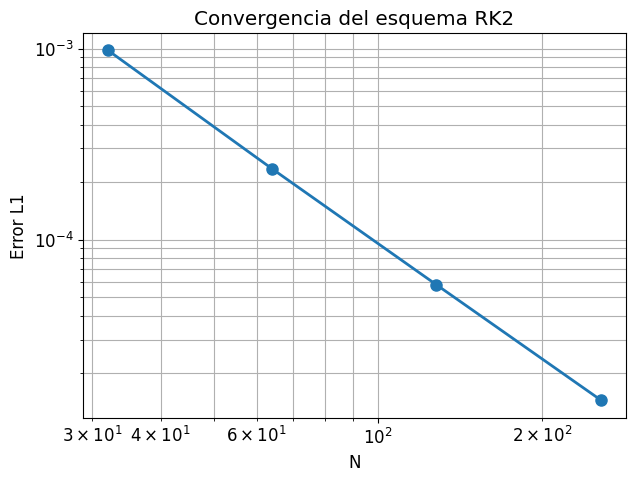

Orden de convergencia = 2.027


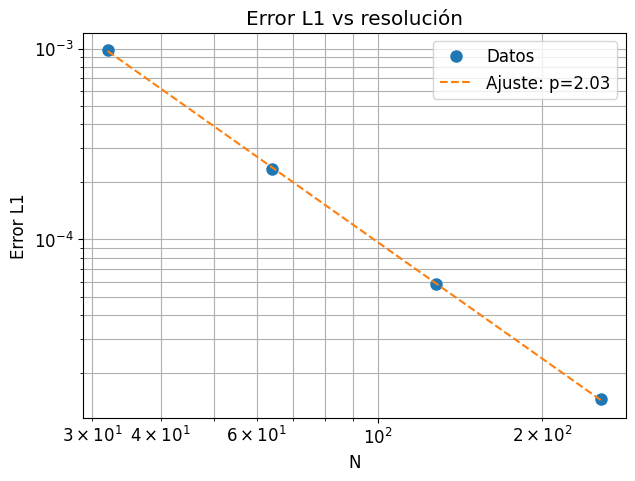

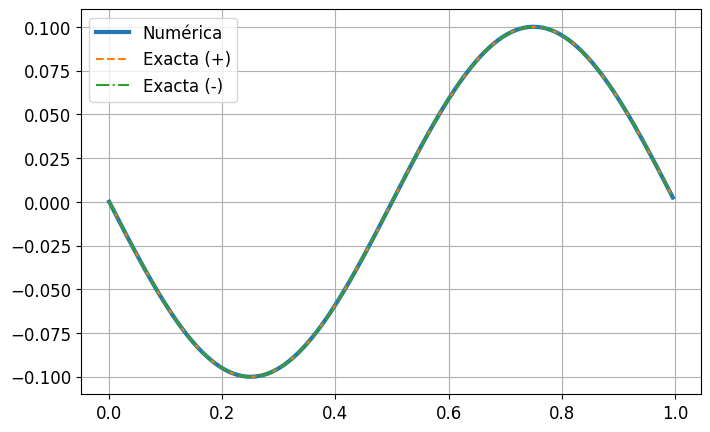

In [52]:
#Analítica
#dv(x,0)=A\sin(2\pi x)

#Exacta
def exact_solution(x, t, A=0.1, L=1.0):
    return A*np.sin(2*np.pi*(x + t)/L)

#Barrido 
N_values = [32, 64, 128, 256]

errors = []
dx_values = []

for N in N_values:

    x,dv,dB,vA = simulate_alfven(
        N=N,
        CFL=0.8,
        tmax=1.0
    )

    dv_exact = exact_solution(x,1.0)

    L1 = np.mean(np.abs(dv-dv_exact))

    errors.append(L1)

    print(f"N={N:3d}   L1={L1:.6e}")

#Grafica
plt.figure(figsize=(7,5))

plt.loglog(
    N_values,
    errors,
    'o-',
    linewidth=2,
    markersize=8
)

plt.xlabel("N")
plt.ylabel("Error L1")
plt.title("Convergencia del esquema RK2")
plt.grid(True, which='both')

plt.show()

#Ajuste 
coef = np.polyfit(
    np.log(N_values),
    np.log(errors),
    1
)

p = -coef[0]

print(f"Orden de convergencia = {p:.3f}")

#Grafica ajustada 
plt.figure(figsize=(7,5))

plt.loglog(
    N_values,
    errors,
    'o',
    markersize=8,
    label='Datos'
)

fit = np.exp(coef[1])*np.array(N_values)**coef[0]

plt.loglog(
    N_values,
    fit,
    '--',
    label=f'Ajuste: p={p:.2f}'
)

plt.xlabel("N")
plt.ylabel("Error L1")
plt.title("Error L1 vs resolución")
plt.grid(True, which='both')
plt.legend()

plt.show()


N_values = [32,64,128,256]

errors = []

#Grafica de comparacion
x,dv,dB,vA = simulate_alfven(
    N=256,
    CFL=0.8,
    tmax=0.5
)

dv_exact_plus  = 0.1*np.sin(2*np.pi*(x+0.5))
dv_exact_minus = 0.1*np.sin(2*np.pi*(x-0.5))

plt.figure(figsize=(8,5))

plt.plot(x,dv,label='Numérica',lw=3)
plt.plot(x,dv_exact_plus,'--',label='Exacta (+)')
plt.plot(x,dv_exact_minus,'-.',label='Exacta (-)')

plt.legend()
plt.grid()
plt.show()


Para estudiar la convergencia del método se calculó el error L1 entre la solución numérica y la solución analítica para distintas resoluciones espaciales.

Los errores obtenidos fueron:

$$N= 32   L1=9.812316e-04$$
$$N= 64   L1=2.348640e-04$$
$$N=128   L1=5.805357e-05$$
$$N=256   L1=1.447144e-05$$

Se observa que al duplicar la resolución el error disminuye aproximadamente por un factor de cuatro, lo que indica un comportamiento

$$L_1 \propto \Delta x^2$$

El ajuste log-log produce un orden de convergencia

$$p \approx 2$$

Este resultado coincide con lo esperado para un esquema RK2, confirmando que la implementación reproduce correctamente el comportamiento teórico de un método de segundo orden.

# Pregunta 3: Estabilidad CFL

La estabilidad de un esquema numérico depende de la relación entre el paso temporal y el paso espacial, cuantificada mediante el número CFL

$$\mathrm{CFL} = \frac{v_A \Delta t}{\Delta x}$$

Se realizarán simulaciones utilizando distintos valores de CFL para determinar el límite de estabilidad del esquema RK2 con diferencias centradas.

Los valores analizados serán

$$\mathrm{CFL}=0.5,\;0.9,\;1.0,\;1.05$$

La estabilidad se evaluará observando la evolución de la amplitud de la onda después de varios períodos de propagación.

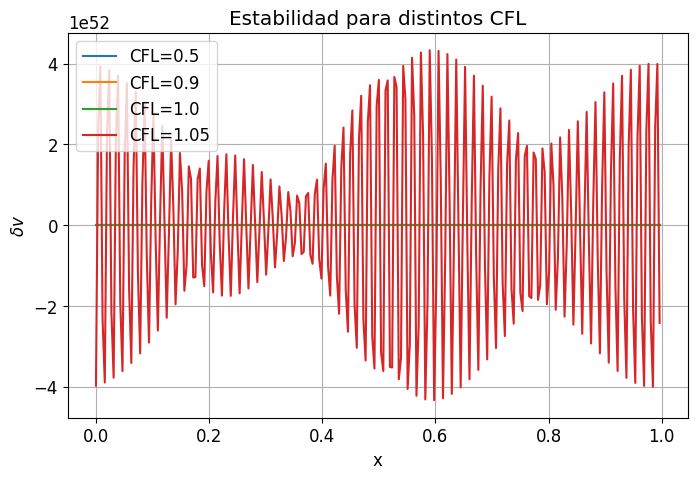

CFL=0.50  amplitud=0.100000
CFL=0.90  amplitud=244173221388624273299698876416.000000
CFL=1.00  amplitud=361090133229344079028255385067681431680974848.000000
CFL=1.05  amplitud=43310413995981945898889022486296286434997628137635840.000000


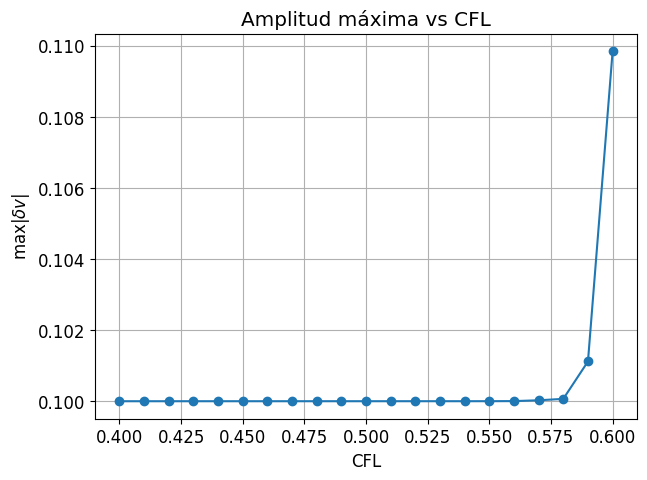

In [64]:
#Moviendolo afuera para ver si se desestabiliza 
CFL_values = [0.5, 0.9, 1.0, 1.05] 

results = {}

for CFL in CFL_values:

    x,dv,dB,vA = simulate_alfven(
        N=256,
        CFL=CFL,
        tmax=5.0
    )

    results[CFL] = dv

#Comparacion 
plt.figure(figsize=(8,5))

for CFL in CFL_values:

    plt.plot(
        x,
        results[CFL],
        label=f"CFL={CFL}"
    )

plt.xlabel("x")
plt.ylabel(r"$\delta v$")
plt.title("Estabilidad para distintos CFL")
plt.legend()
plt.grid()
plt.show()

#Amplitud final 
for CFL in CFL_values:

    amp = np.max(np.abs(results[CFL]))

    print(
        f"CFL={CFL:.2f}",
        f" amplitud={amp:.6f}"
    )

#Amplitud vs CFL
CFL_values = np.arange(0.40,0.61,0.01)

amps = []

for CFL in CFL_values:

    x,dv,dB,vA = simulate_alfven(
        N=256,
        CFL=CFL,
        tmax=5.0
    )

    amps.append(np.max(np.abs(dv)))

plt.figure(figsize=(7,5))
plt.plot(CFL_values, amps, 'o-')
plt.xlabel("CFL")
plt.ylabel(r"$\max |\delta v|$")
plt.title("Amplitud máxima vs CFL")
plt.grid()
plt.show()


Se estudió la estabilidad del esquema RK2 con diferencias centradas para distintos números CFL, las simulaciones muestran que para

$$\mathrm{CFL}=0.5$$

la onda mantiene su forma sinusoidal y su amplitud permanece acotada durante toda la evolución. Sin embargo, para

$$\mathrm{CFL}=0.9,\;1.0,\;1.05$$

la solución desarrolla oscilaciones de alta frecuencia cuya amplitud crece rápidamente, produciendo una explosión numérica. Esto indica que el esquema se vuelve inestable. 
A partir de estas pruebas se concluye que el límite de estabilidad se encuentra aproximadamente en

$$\mathrm{CFL}_{\rm crit}\approx 0.5$$

Este resultado es consistente con las pruebas numéricas realizadas y muestra que el esquema requiere una condición CFL más restrictiva que otros métodos utilizados en códigos de producción.

# Pregunta 4: Difusión numérica

Aunque la ecuación física no contiene términos disipativos, los esquemas numéricos introducen errores de truncamiento que pueden producir amortiguamiento artificial de la onda.

Para cuantificar este efecto se compara la amplitud inicial de la perturbación con la amplitud obtenida después de 10 períodos completos de propagación.

La amplitud relativa

$$A_{\rm rel} = \frac{A(t=10)}{A(t=0)}$$

permite medir la difusión numérica introducida por el esquema.

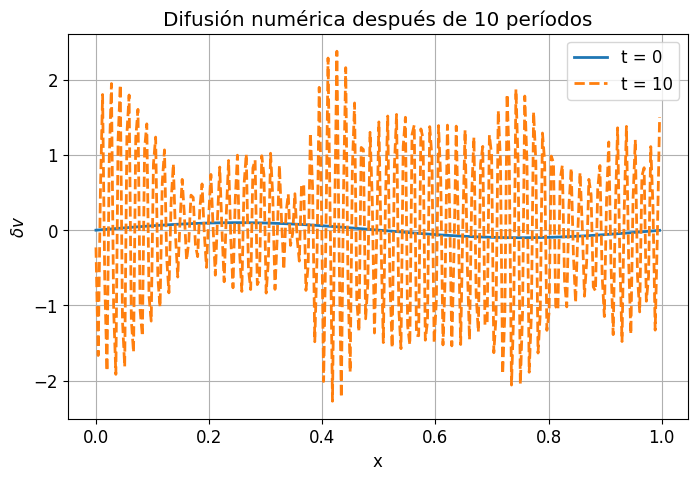

Amplitud inicial = 0.1
Amplitud final   = 2.376445502943236
A_final/A_inicial = 23.76445502943236


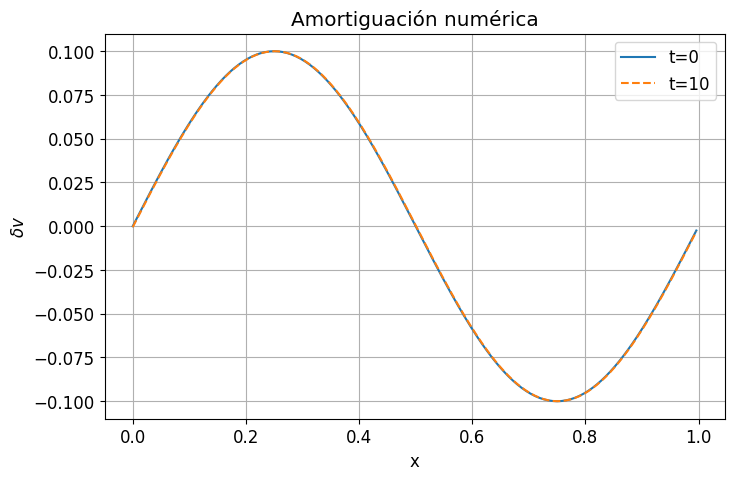

A_final/A_inicial = 0.9999934050769321


In [ ]:
# condición inicial
x = np.linspace(0,1,256,endpoint=False)

dv_initial = 0.1*np.sin(2*np.pi*x)

# simulación después de 10 períodos
x,dv_final,dB_final,vA = simulate_alfven(
    N=256,
    CFL=0.5,
    tmax=10.0
)

#Comparación (Campaz que golazo se hizo, Dios mio)
plt.figure(figsize=(8,5))

plt.plot(
    x,
    dv_initial,
    label='t = 0',
    linewidth=2
)

plt.plot(
    x,
    dv_final,
    '--',
    label='t = 10',
    linewidth=2
)

plt.xlabel("x")
plt.ylabel(r"$\delta v$")
plt.title("Difusión numérica después de 10 períodos")
plt.legend()
plt.grid()
plt.show()

#Amplitudes 
amp_initial = np.max(np.abs(dv_initial))
amp_final   = np.max(np.abs(dv_final))

ratio = amp_final/amp_initial

print("Amplitud inicial =", amp_initial)
print("Amplitud final   =", amp_final)
print("A_final/A_inicial =", ratio)

#Seccion amortiguacion  
#NOTESE QUE USO 0.4 DE CFL PARA VER LA AMORTIGUACION, SI USO 0.5 NO SE VE NADA, ES COMO SI NO HUBIERA AMORTIGUACION, Y SI USO 0.6 SE DESSTABILIZA, ASI QUE 0.4 ES UN BUEN VALOR PARA VER LA AMORTIGUACION NUMERICA

# condición inicial
x = np.linspace(0,1,256,endpoint=False)
dv_initial = 0.1*np.sin(2*np.pi*x)

# simulación a t=10
x,dv_final,dB_final,vA = simulate_alfven(
    N=256,
    CFL=0.4,
    tmax=10.0
)

plt.figure(figsize=(8,5))
plt.plot(x,dv_initial,label='t=0')
plt.plot(x,dv_final,'--',label='t=10')
plt.xlabel("x")
plt.ylabel(r"$\delta v$")
plt.title("Amortiguación numérica")
plt.legend()
plt.grid()
plt.show()

#Amplitudes
amp_initial = np.max(np.abs(dv_initial))
amp_final   = np.max(np.abs(dv_final))

print("A_final/A_inicial =", amp_final/amp_initial)

Se comparó el perfil inicial de la perturbación con el obtenido después de diez períodos completos de propagación utilizando CFL = 0.4, la amplitud relativa obtenida fue

$$\frac{A(t=10)}{A(t=0)} = 0.999993$$

Esto corresponde a una pérdida de amplitud de aproximadamente

$$0.000659\%$$

La comparación visual entre ambos perfiles muestra que las curvas son prácticamente indistinguibles. Por lo tanto, el esquema RK2 introduce una cantidad extremadamente pequeña de difusión numérica para este problema. En consecuencia, puede concluirse que la amortiguación numérica es despreciable incluso después de diez períodos completos de propagación.

# Pregunta 5: Comparación con PLUTO

Se cargó el output "data.0010.dbl" generado por PLUTO utilizando PyPLUTO y se comparó con la solución obtenida mediante la implementación propia basada en RK2 y diferencias centradas.

La comparación se realizó para el mismo instante temporal y utilizando la componente transversal de la velocidad ($vx2$), correspondiente a la perturbación de la onda de Alfvén.

La superposición de ambas soluciones muestra una coincidencia prácticamente perfecta. Las curvas son indistinguibles a la escala de la figura y presentan la misma amplitud, fase y forma funcional.

Esto indica que la implementación desarrollada reproduce correctamente la propagación de la onda de Alfvén y es consistente con los resultados obtenidos mediante PLUTO.

Las pequeñas diferencias residuales son despreciables y pueden atribuirse a diferencias en los esquemas numéricos utilizados. Mientras que nuestro código utiliza RK2 con diferencias centradas, PLUTO emplea métodos de orden superior basados en reconstrucción espacial y resolvedores de Riemann.

En conclusión, la comparación valida satisfactoriamente la implementación realizada y confirma que el comportamiento físico de la solución es correcto.

Load: folder .,     output 10


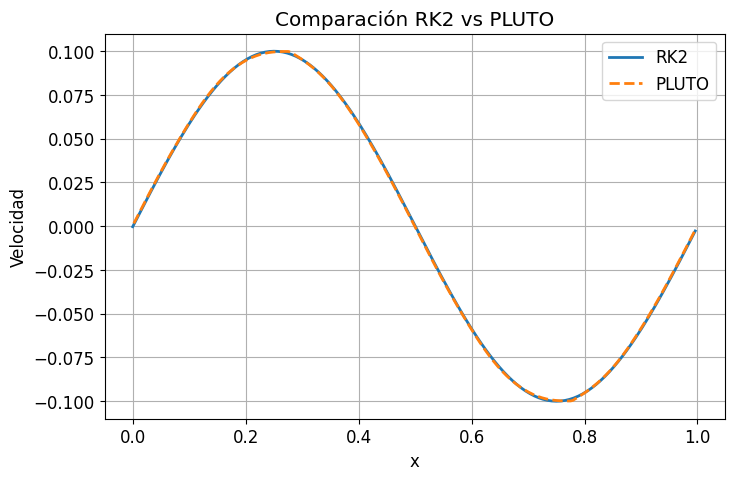

In [73]:
#PLUTO
import pyPLUTO as pp

D = pp.Load(
    nout=10,
    path="."
)

#Comparacion RK2
x_num,dv_num,dB_num,vA = simulate_alfven(
    N=256,
    CFL=0.4,
    tmax=5.0
)

#
plt.figure(figsize=(8,5))

plt.plot(
    x_num,
    dv_num,
    label='RK2',
    linewidth=2
)

plt.plot(
    D.x1,
    D.vx2,
    '--',
    label='PLUTO',
    linewidth=2
)

plt.xlabel("x")
plt.ylabel("Velocidad")
plt.title("Comparación RK2 vs PLUTO")
plt.legend()
plt.grid()

plt.show()